In [1]:
# Import required libraries
import sys
import os
from pathlib import Path
import gzip
import shutil

# Install required packages
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "polars", "folium"])

# Add project path
sys.path.append('../')

# Import configuration
from script.conf import *

# Import Polars for data processing
import polars as pl
import pandas as pd

print("Using Polars for data processing")

Using Polars for data processing


# Processing Raw Mobile Positioning Data (MPD) - Polars Version

## Summary

This notebook cleans and standardizes raw Mobile Positioning Data (MPD) so it can be used in the downstream QA, anchoring, and indicator workflows. It supports two common input structures: event records already merged with cell coordinates, or event records and cell coordinates provided as separate files.

The workflow reads the raw data with `Polars`, parses timestamps, harmonizes location fields, rounds coordinates for resilience when cell identifiers are missing, and removes duplicate rows. It then applies the standard filtering rules used in this project for anomaly subscribers, random records, and short-stay tourist-like patterns before writing the cleaned dataset for the next notebooks.

The notebook is designed for regular production-style processing of one reporting period at a time, typically one month, but the same logic can be used for any time window as long as the corresponding input files and configuration values are provided.

## Requirements

- Python with Polars library installed
- Raw MPD input files in CSV or Parquet format, following one of the supported structures below.

## Data Structure

To work with Mobile Positioning Data (MPD), the minimum required fields are listed below:

In [2]:
# Check for data files
try:
    try:
        geojson_path = Path(GEOJSON_FILE)
        geojson_gz_path = Path(str(geojson_path) + ".gz")
        if (not geojson_path.exists()) and geojson_gz_path.exists():
            geojson_path.parent.mkdir(parents=True, exist_ok=True)
            with gzip.open(geojson_gz_path, "rb") as src, open(geojson_path, "wb") as dst:
                shutil.copyfileobj(src, dst)
            print(f"Decompressed GeoJSON file: {geojson_gz_path} -> {geojson_path}")
        elif geojson_path.exists():
            print(f"GeoJSON file found: {geojson_path}")
        elif geojson_gz_path.exists():
            print(f"GeoJSON gzip file found: {geojson_gz_path}")
        else:
            print(f"GeoJSON file not found yet: {geojson_path}")
    except Exception as exc:
        print(f"Could not prepare GeoJSON file from gzip: {exc}")

    flag = os.path.exists(BASE_PATH+RAW_FILE_PATH)
    if flag:
        USE_MERGED = True
    else:
        USE_MERGED = False
        print("Merged file not found. Will proceed the data using option unmerged. Please update configuration of RAW_CELLS_PATH and RAW_SUBS_PATH")
except:
    USE_MERGED = False
    print("Merged file not found. Will proceed the data using option unmerged. Please update configuration of RAW_CELLS_PATH and RAW_SUBS_PATH")

print("Use Merged: {}".format(USE_MERGED))

GeoJSON file found: ../data/gadm41_RWA_2.json
Use Merged: True


The setup above decides whether the notebook should read a single merged file or reconstruct the MPD table from separate record and cell files. This early branch matters because the rest of the notebook assumes one common schema regardless of the source layout.

## Read Raw MPD
The following code code sets a `BASE_PATH` variable to define the parent directory where data files are located. Then, it reads a specific CSV file into a `DataFrame` object using Polars.

If the available data is already in combined form (**option 1**), in this example refer to the CSV file `"MPD_sample.csv"`, which will be loaded from `BASE_PATH`. 

If the available data is still separated between records and cells (**option 2**), in this example refer to the CSV file `"MPD_sample_records.csv"` and `"MPD_sample_cells.csv"`, which will also be loaded from `BASE_PATH`. 

The resulting `DataFrame` is printed to display the first five rows in a tabular format, and then the total count of records in the `DataFrame` is printed using the `height` property.

### Option 1: Merged Data

In [3]:
import polars as pl
from datetime import datetime

if USE_MERGED:
    # Read the data using Polars
    # For gzipped files, we need to handle decompression
    if RAW_FILE_PATH.endswith('.gz'):
        # Read gzipped CSV file
        df = pl.read_csv(BASE_PATH + RAW_FILE_PATH, 
                         schema_overrides={
                             "msisdn": pl.Utf8,
                             "datetime": pl.Utf8,
                             "cell_id": pl.Utf8,
                             "latitude": pl.Float64,
                             "longitude": pl.Float64,
                             "data_type": pl.Utf8,
                             "service": pl.Utf8
                         })
    else:
        # Read regular CSV file
        df = pl.read_csv(BASE_PATH + RAW_FILE_PATH,
                         schema_overrides={
                             "msisdn": pl.Utf8,
                             "datetime": pl.Utf8,
                             "cell_id": pl.Utf8,
                             "latitude": pl.Float64,
                             "longitude": pl.Float64,
                             "data_type": pl.Utf8,
                             "service": pl.Utf8
                         })

    # Parse datetime column - try multiple formats
    datetime_formats = [
        "%Y-%m-%d %H:%M:%S",  # Standard format
        "%m/%d/%Y %H:%M:%S",  # US format with seconds
        "%m/%d/%Y %H:%M",     # US format without seconds
        "%m/%d/%Y %I:%M:%S %p",  # 12-hour format with seconds
        "%m/%d/%Y %I:%M %p",     # 12-hour format without seconds
    ]
    
    # Try to parse datetime with different formats
    datetime_parsed = None
    for fmt in datetime_formats:
        try:
            datetime_parsed = df.select(
                pl.col("datetime").str.strptime(pl.Datetime, fmt)
            ).to_series()
            print(f"Successfully parsed datetime with format: {fmt}")
            break
        except:
            continue
    
    if datetime_parsed is not None:
        # Update the dataframe with parsed datetime
        df = df.with_columns([
            datetime_parsed.alias("datetime")
        ])
    else:
        print("Warning: Could not parse datetime column, keeping as string")

    # Display first 5 rows
    print(df.head(5))
    print("Number of records: {}".format(len(df)))
    
    # Count unparsed rows if datetime was successfully parsed
    if datetime_parsed is not None:
        unparsed_count = df.filter(pl.col("datetime").is_null()).height
        print("Unparsed rows: {}".format(unparsed_count))

Successfully parsed datetime with format: %Y-%m-%d %H:%M:%S
shape: (5, 7)
┌───────────────────┬─────────────────────┬─────────┬──────────┬───────────┬───────────┬─────────┐
│ msisdn            ┆ datetime            ┆ cell_id ┆ latitude ┆ longitude ┆ data_type ┆ service │
│ ---               ┆ ---                 ┆ ---     ┆ ---      ┆ ---       ┆ ---       ┆ ---     │
│ str               ┆ datetime[μs]        ┆ str     ┆ f64      ┆ f64       ┆ str       ┆ str     │
╞═══════════════════╪═════════════════════╪═════════╪══════════╪═══════════╪═══════════╪═════════╡
│ subscribers_00312 ┆ 2026-08-01 00:32:00 ┆ 1166    ┆ -1.951   ┆ 30.062    ┆ IPDR      ┆ 4G      │
│ subscribers_00312 ┆ 2026-08-01 12:15:00 ┆ 1264    ┆ -1.955   ┆ 30.097    ┆ IPDR      ┆ 4G      │
│ subscribers_00312 ┆ 2026-08-01 18:35:00 ┆ 1166    ┆ -1.951   ┆ 30.062    ┆ CDR       ┆ 4G      │
│ subscribers_00312 ┆ 2026-08-02 14:03:00 ┆ 1665    ┆ -1.95    ┆ 30.06     ┆ CDR       ┆ 3G      │
│ subscribers_00312 ┆ 2026-08-02 18

### Option 2: Separated Data

In [4]:
if USE_MERGED==False:
    # Read records data
    df_records = pl.read_csv(BASE_PATH + RAW_SUBS_PATH,
                             schema_overrides={
                                 "msisdn": pl.Utf8,
                                 "datetime": pl.Datetime,
                                 "cell_id": pl.Utf8,
                                 "data_type": pl.Utf8
                             })

    # Read cells data
    df_cells = pl.read_csv(BASE_PATH + RAW_CELLS_PATH,
                           schema_overrides={
                               "cell_id": pl.Utf8,
                               "latitude": pl.Float64,
                               "longitude": pl.Float64,
                               "service": pl.Utf8
                           })

    # Join records with cells data
    df = df_records.join(df_cells, on="cell_id", how="left")

    # Reorder columns
    df = df.select(['msisdn', 'datetime', 'cell_id', 'latitude', 'longitude', 'data_type', 'service'])

    # Display first 5 rows
    print(df.head(5))
    print("Number of records: {}".format(len(df)))

The rounding and `date` derivation step standardizes the spatial and temporal columns before any profiling starts. Rounding coordinates here reduces accidental micro-precision differences that would otherwise inflate distinct cell-location counts later in the notebook.

### Rounding Decimal And Create New Column

To start working with raw MPD, we need to rounding the decimal into standard precision (4 decimals, equal to 11.1 m) and create new column for identifying the date.

The code takes the DataFrame `df` and uses the `.with_columns()` method to add three new columns to it. The first two columns are 'latitude' and 'longitude', and they are created by rounding the existing 'latitude' and 'longitude' columns to 4 decimal places using the `pl.col().round()` method from Polars, and then assigning these rounded values to the new columns.

The third column is 'date', which is created by converting the existing 'datetime' column to a date type using the `cast()` function from Polars, and then assigning the converted values to the new column.

In [5]:
# Round the 'latitude' and 'longitude' columns to 4 decimal places and create a 'date' column
df = df.with_columns([
    pl.col('latitude').round(4).alias('latitude'),
    pl.col('longitude').round(4).alias('longitude'),
    pl.col('datetime').cast(pl.Date).alias('date')
])

# Show the first 5 rows
df.head(5)

msisdn,datetime,cell_id,latitude,longitude,data_type,service,date
str,datetime[μs],str,f64,f64,str,str,date
"""subscribers_00312""",2026-08-01 00:32:00,"""1166""",-1.951,30.062,"""IPDR""","""4G""",2026-08-01
"""subscribers_00312""",2026-08-01 12:15:00,"""1264""",-1.955,30.097,"""IPDR""","""4G""",2026-08-01
"""subscribers_00312""",2026-08-01 18:35:00,"""1166""",-1.951,30.062,"""CDR""","""4G""",2026-08-01
"""subscribers_00312""",2026-08-02 14:03:00,"""1665""",-1.95,30.06,"""CDR""","""3G""",2026-08-02
"""subscribers_00312""",2026-08-02 18:48:00,"""1166""",-1.951,30.062,"""CDR""","""4G""",2026-08-02


### Drop Duplicate Rows

This code utilizes the `unique()` method to efficiently eliminate duplicate rows from the data frame. 
By invoking this method, all duplicate rows are eradicated, leaving only a single instance of each unique row. If there are no changes observed before and after applying this operation, it signifies the absence of any duplicates in the data frame.

In [6]:
# Detect duplicate rows
duplicate_counts = df.group_by(df.columns).agg(pl.len()).filter(pl.col("len") > 1)
print(f"Number of duplicate rows: {len(duplicate_counts)}")
if len(duplicate_counts) > 0:
    print(duplicate_counts.head())

print("Number of records before deduplication: {}".format(len(df)))

# Drop duplicate rows
df = df.unique()

# Display first 5 rows
print("Number of records after deduplication: {}".format(len(df)))
df.head(5)


Number of duplicate rows: 0
Number of records before deduplication: 1905607
Number of records after deduplication: 1905607


msisdn,datetime,cell_id,latitude,longitude,data_type,service,date
str,datetime[μs],str,f64,f64,str,str,date
"""subscribers_00362""",2026-08-20 12:46:00,"""1877""",-1.974,30.223,"""IPDR""","""3G""",2026-08-20
"""subscribers_01000""",2026-08-23 17:36:00,"""1704""",-1.943,30.071,"""CDR""","""3G""",2026-08-23
"""subscribers_01124""",2026-08-03 07:55:00,"""765""",-2.557,28.941,"""IPDR""","""4G""",2026-08-03
"""subscribers_09291""",2026-08-24 09:08:00,"""942""",-1.513,29.655,"""IPDR""","""4G""",2026-08-24
"""subscribers_09499""",2026-08-02 21:00:00,"""853""",-2.312,29.404,"""CDR""","""4G""",2026-08-02


Duplicate detection is done before any caching so the cleaned dataframe represents the cleaned raw input rather than the noisy original load. This is a good place in the workflow to materialize the dataset because most downstream sections reuse the same table repeatedly.

In Polars, we don't need explicit caching like in Spark as Polars is optimized for performance and handles memory management efficiently.

### Exploratory Data Analysis (EDA)

`Exploratory Data Analysis (EDA)` is a crucial process in data science that involves investigating and summarizing the `primary characteristics` of a dataset. The main objective of EDA is to gain insights into the raw data and comprehend its underlying structure, identify patterns, detect anomalies, and develop hypotheses for further analysis.

When processing mobile positioning data, EDA involves examining the dataset to understand the available variables and their distributions, such as the number of unique subscribers, unique cell locations, and the distribution of records. This process can also help to identify any missing or erroneous values and diagnose general patterns within the data.

EDA is an essential step in preparing mobile positioning data for subsequent analysis as it identifies potential issues that require addressing, including data cleaning or imputation, and so on.

#### Checking Number of Unique Subscribers, Cell ID, Data type, & Services

The following operations are performed:
1. Four columns ('msisdn', 'cell_id', 'data_type', and 'service') are selected from the dataframe `df`, which we want to analyze.
2. `n_unique()` function is applied on each of these columns to get the count of unique entities present in them.
3. The obtained values are then renamed, using `alias()` method, to better represent their count metrics.
4. `print()` method is used to display the resulting table in the console.

In [7]:
# Count distinct values for key columns
unique_counts = df.select([
    pl.col('msisdn').n_unique().alias('unique_subscribers'),
    pl.col('cell_id').n_unique().alias('unique_cell_id'),
    pl.col('data_type').n_unique().alias('unique_data_type'),
    pl.col('service').n_unique().alias('unique_service')
])

# Show the counts
unique_counts

unique_subscribers,unique_cell_id,unique_data_type,unique_service
u32,u32,u32,u32
10000,1913,2,3


#### Checking the range of datetime, latitude, & Longitude

This code generates the range values for datetime, latitude, and longitude columns in a given dataframe. 

It does this by performing the following operations:
1. Selecting specific columns from the data frame using `select()`, with each selected value having an alias to rename it.
2. Using Polars' built-in functions `min()` and `max()` along with Polars' `col()` function to select the minimum and maximum values of datetime, latitude, and longitude respectively in the data frame.
3. Renaming each of these selected minimum and maximum values as per their column name with the `alias()` method.
4. Finally, displaying all the selected and renamed values using the `print()` method.

In [8]:
# Generate the range values for datetime, latitude, and longitude
df_range = df.select([
    pl.col('datetime').min().alias('min_datetime'),
    pl.col('datetime').max().alias('max_datetime'),
    pl.col('latitude').min().alias('min_latitude'),
    pl.col('longitude').min().alias('min_longitude'),
    pl.col('latitude').max().alias('max_latitude'),
    pl.col('longitude').max().alias('max_longitude'),
])

df_range

min_datetime,max_datetime,min_latitude,min_longitude,max_latitude,max_longitude
datetime[μs],datetime[μs],f64,f64,f64,f64
2026-08-01 00:00:00,2026-08-31 23:59:00,-2.786,28.876,-1.08,30.837


In [9]:
# Importing the folium library for creating interactive maps.
import folium

# Selecting specific columns from the dataframe and dropping duplicate entries based on latitude and longitude. Converting the result to a Pandas dataframe.
df_cell_used = df.select(['cell_id','latitude','longitude']).unique(['latitude','longitude']).to_pandas()

# Converting the df_range dataframe to a Pandas dataframe for further processing.
df_range_pd = df_range.to_pandas()

# Defining the coordinates for the corners of a rectangular area.
upper_left = (df_range_pd['min_latitude'].iloc[0], df_range_pd['min_longitude'].iloc[0])
upper_right = (df_range_pd['max_latitude'].iloc[0], df_range_pd['min_longitude'].iloc[0])
lower_left = (df_range_pd['min_latitude'].iloc[0], df_range_pd['max_longitude'].iloc[0])
lower_right = (df_range_pd['max_latitude'].iloc[0], df_range_pd['max_longitude'].iloc[0])

# Storing the corner coordinates in a list representing the edges of the rectangular area.
edges = [upper_left, upper_right, lower_right, lower_left]

# Creating a folium map centered at a specified location with a defined zoom level and using a specific tileset.
cell_location = folium.Map(
    location=[df_range_pd['min_latitude'].iloc[0], df_range_pd['min_longitude'].iloc[0]], # Centering the map at the minimum latitude and longitude coordinates.
    zoom_start=10,  # Setting the initial zoom level of the map.
    # tiles="Cartodb Positron"  # The "Cartodb Positron" require API KEYS
)

# Adding a polygon to the map, representing the rectangular area defined by the edges with specified color and fill properties.
folium.Polygon(locations=edges, color='#ff7800', fill=True, fill_color='#ffff00', fill_opacity=0.2).add_to(cell_location)
# folium.Rectangle(bounds=edges, color='#ff7800', fill=True, fill_color='#ffff00', fill_opacity=0.2).add_to(cell_location)

# Iterating through the rows of the df_cell_used dataframe and adding markers to the map for each cell tower location.
for i, row in df_cell_used.sample(100).iterrows():
    folium.Marker(
        location=[row["latitude"], row["longitude"]],  # Specifying the coordinates of the marker based on its latitude and longitude.
        popup=row['cell_id'],  # Displaying the tower ID as the popup message.
        icon=folium.Icon(icon='signal')  # Defining the icon to use for each marker (signal).
    )\
    .add_to(cell_location)  # Adding the marker to the map.

# Displaying the final map with all the added elements (polygon and markers).
cell_location

The exploratory checks above answer two basic questions before filtering begins:

- how large and diverse is the dataset,
- do the timestamps and coordinates fall into a plausible range.

That context is important because later anomaly thresholds are easier to interpret when the baseline volume and geography are already visible.

### Explore Records Distribution

The code below will group a dataframe called `df` by the `'msisdn'` column and computes various count functions for other columns. 

The resulting dataframe `df_user_dist` is created using Polars `group_by()` method, which groups the data by 'msisdn' column. Then it applies several aggregate functions to each group of data using the `agg()` method. 

In particular, the following five aggregate functions are applied to different columns:
- `len()` - counts the number of rows for each group
- `n_unique()` - counts the number of distinct values for each group

The resulting columns are then renamed to more meaningful names using the `alias()` method.

Finally, the result from Polars dataframe is collected into pandas dataframe by using the `to_pandas()` method. This data will be used for plotting the records distribution to identify anomaly subscribers such as robot or tourist.

The `.head()` method is called on the resulting pandas dataframe `df_user_dist` to display the first 5 rows of data from it.

In [10]:
# This code groups the dataframe df by 'msisdn' column and applies various count functions for other columns.
df_user_dist = (
    df.group_by("msisdn")
      .agg([
          pl.len().alias("records"),
          pl.col("date").n_unique().alias("unique_date"),
          (pl.len() / pl.col("date").n_unique()).alias("avg_records_day"),
          pl.col("cell_id").n_unique().alias("unique_cell_id"),
          pl.col("data_type").n_unique().alias("unique_data_type"),
          pl.col("service").n_unique().alias("unique_service"),
      ])
)

# Convert to pandas for plotting
df_user_dist_pd = df_user_dist.to_pandas()
df_user_dist_pd = df_user_dist_pd.sort_values("avg_records_day", ascending=False)

df_user_dist_pd.head()

,msisdn,records,unique_date,avg_records_day,unique_cell_id,unique_data_type,unique_service
3605,subscribers_06009,7775,31,250.806452,1,1,1
3945,subscribers_01847,7748,31,249.935484,1,1,1
1249,subscribers_00026,7744,31,249.806452,1,2,1
1406,subscribers_02451,7735,31,249.516129,1,2,1
2518,subscribers_08607,7725,31,249.193548,1,1,1


To see the distribution of the records per subscribers, we can create a histogram of the 'records' column of df_user_dist data.

When analyzing the distribution of the number of records in Mobile Positioning Data (MPD), it's possible to observe certain patterns that may align with `common anomalies` that often occur. These patterns can provide insights into potential issues or irregularities within the data.

In a healthy dataset, the number of records may exhibit a relatively `uniform distribution` across different subscribers, locations, etc. This indicates a consistent and expected behavior of data collection. If there is a deviation from the uniform distribution, such as a significant difference in the number of records in some particular subscribers compared to the others, it may indicate an issue worth investigating. For example, a high frequency events from a subscribers in a single cell location could be due to the use of robot system to interact with mobile network.

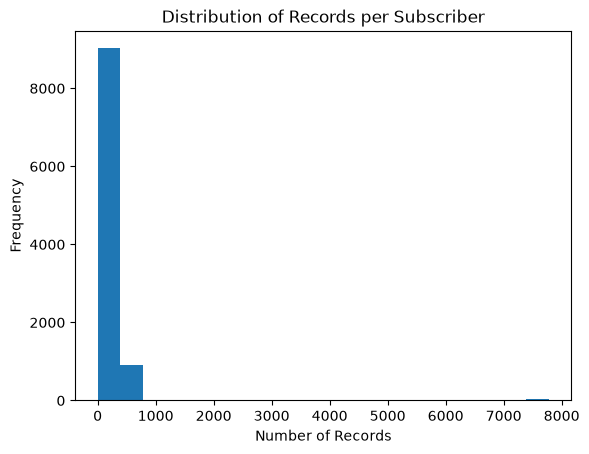

In [11]:
# Creates a histogram of the 'records' column of df_user_dist data frame with 20 bins
import matplotlib.pyplot as plt
plt.hist(df_user_dist_pd['records'], bins=20)
plt.xlabel('Number of Records')
plt.ylabel('Frequency')
plt.title('Distribution of Records per Subscriber')
plt.show()

After exploring the distribution at the user level, we can explore more deeper by checking the distribution at cell_id level for each subscribers, so that we can see more granular pattern and identify the potential anomaly subscribers inside the data, such as robots or tourist.

This code line performs the following tasks:

- It groups `df` by unique combinations of `'msisdn'`, `'date'`, and `'cell_id'` columns using `group_by()` function.
- After grouping, it computes aggregation functions on each group. Here, it calculates the count of records for each unique combination of the three columns. Additionally, it counts the number of distinct entries in the 'data_type' and 'service' columns to get the number of unique data types and services in each group.
- Finally, it collects the aggregated data from Polars dataframe into a new Pandas dataframe using `to_pandas()` function.

The record-distribution section moves from subscriber-level volume to subscriber-by-day-by-cell patterns. That deeper view is useful because robot-like behavior is usually not visible only from total event counts; it becomes clearer when a subscriber repeatedly produces unusually many events in the same place on the same day.

In [12]:
# Groups the df data frame by unique combinations of 'msisdn', 'date', and 'cell_id' columns
df_subs_cell_date = df \
  .group_by(['msisdn','date','cell_id']) \
  .agg([
      # Counts the total number of records for each unique value of 'msisdn' and renames that column as 'records'
      pl.len().alias('records'),
      # Counts the number of unique 'data_type' values for each group and renames that column as 'unique_data_type'
      pl.col('data_type').n_unique().alias('unique_data_type'),
      # Counts the number of unique 'service' values for each group and renames that column as 'unique_service'
      pl.col('service').n_unique().alias('unique_service')
  ]).to_pandas() # collect data from polars into pandas

# Sorts the resulting data frame by the 'records' column in descending order
df_subs_cell_date = df_subs_cell_date.sort_values('records',ascending=False)

df_subs_cell_date.head()

,msisdn,date,cell_id,records,unique_data_type,unique_service
137400,subscribers_04658,2026-08-05,1664,286,1,1
539318,subscribers_01847,2026-08-19,910,284,1,1
630591,subscribers_00834,2026-08-04,1241,283,1,1
84294,subscribers_08840,2026-08-07,1014,283,1,1
211806,subscribers_08776,2026-08-27,1657,283,2,1


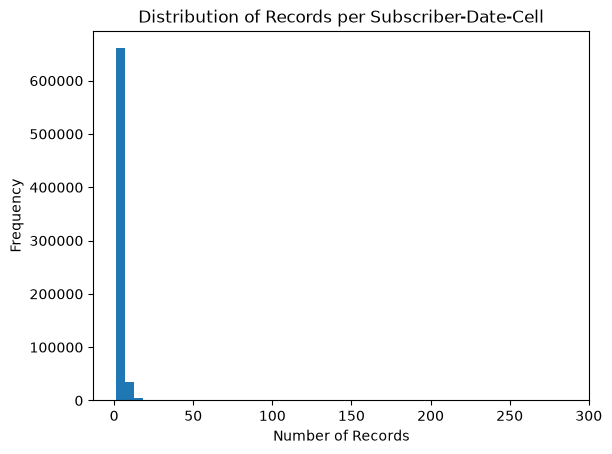

In [13]:
# Selects the 'records' column from the df_subs_patterns dataframe and plots a histogram with 100 bins
plt.hist(df_subs_cell_date['records'], bins=50)
plt.xlabel('Number of Records')
plt.ylabel('Frequency')
plt.title('Distribution of Records per Subscriber-Date-Cell')
plt.show()

### Remove Anomaly Subscribers

This section applies several exclusion rules that target different patterns in the raw event stream. The rules do not all remove the same kind of object:

1. `Filtering Robot` removes whole subscribers whose activity is implausibly concentrated at one site.
2. `Filter Random Cell Events` removes sparse subscriber-cell traces that do not repeat often enough to be useful for later inference.
3. `Filtering Tourists Subscribers step 1` removes subscribers with extremely low overall activity volume in the observation window. This step is best understood as a very-low-frequency-user filter.
4. `Filtering Tourists Subscribers step 2` removes short-stay patterns based on too few active days and too short a consecutive presence window. This is the stricter tourist-like presence filter.

Keeping these filters separate makes it easier to understand whether rows are being removed because of abnormal intensity, isolated random traces, very sparse activity, or short-duration presence.

#### Filtering Robot

This step identifies subscribers whose activity is unusually intense at a single site. The rule is applied at the subscriber-site-day level: if a subscriber exceeds the configured `ROBOT_THRESHOLD` for the maximum number of events observed at one site in one day, that subscriber is classified as a robot-like or machine-like account.

The important consequence is that this is a **subscriber-level exclusion**. Once a subscriber is flagged here, all rows for that `msisdn` are removed from the event dataset before any later filters are applied.

The code:

1. builds a summary of the maximum number of records per subscriber at a single site on a single day,
2. selects subscribers whose `max_records` exceed `RAW_CONF["ROBOT_THRESHOLD"]`,
3. reports how many subscribers were flagged, and
4. removes every event belonging to those subscribers from the raw MPD table.

![Robot filtering](../assets/images/Robot%20filtering.png)

In [14]:
print("Robot Threshold: {}".format(RAW_CONF['ROBOT_THRESHOLD']))

Robot Threshold: 250


In [15]:
# Groups the df_subs_patterns dataframe by 'msisdn' and calculates aggregated statistics for the 'records' column
df_subs_cell_date_stats = df_subs_cell_date.groupby('msisdn').agg({
    'records': ['min', 'median', 'max']
}).reset_index()
df_subs_cell_date_stats.columns = ['msisdn', 'min_records', 'med_records', 'max_records']

# Prints out the resulting dataframe
df_subs_cell_date_stats = df_subs_cell_date_stats.sort_values('max_records',ascending=False)
df_subs_cell_date_stats.head(10)

,msisdn,min_records,med_records,max_records
4658,subscribers_04658,199,261.0,286
1847,subscribers_01847,207,260.0,284
8776,subscribers_08776,207,255.0,283
8840,subscribers_08840,203,265.0,283
834,subscribers_00834,194,255.0,283
6708,subscribers_06708,197,257.0,282
1765,subscribers_01765,197,258.0,281
8879,subscribers_08879,195,256.0,281
2681,subscribers_02681,201,260.0,280
9595,subscribers_09595,189,260.0,280


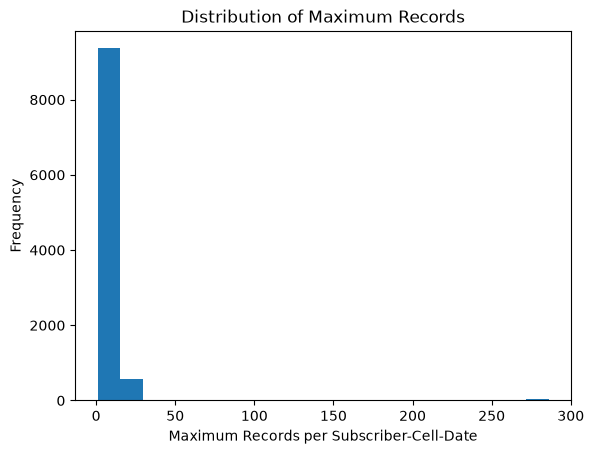

In [16]:
plt.hist(df_subs_cell_date_stats['max_records'], bins=20)
plt.xlabel('Maximum Records per Subscriber-Cell-Date')
plt.ylabel('Frequency')
plt.title('Distribution of Maximum Records')
plt.show()

In [17]:
# Select all rows from the DataFrame `df_subs_stats` where 'max_records' is greater than the robot threshold and assign it to a new DataFrame called `df_robots`.
df_robots = df_subs_cell_date_stats[df_subs_cell_date_stats['max_records']>RAW_CONF['ROBOT_THRESHOLD']]

# Calculate the number of rows in the `df_robots` DataFrame and store the value in a variable called `n_robots`.
n_robots = len(df_robots)

# Calculate the percentage of robots (subscribers with more than the robot threshold of events in a single site at a single day) and store it in a variable called `prop_robots`.
prop_robots = n_robots/(len(df_subs_cell_date_stats))*100

# Print out detection message which shows the total number of detected robots and their percentage.
print('Detecting {} subscribers ({:.2f}%) with more than {} events in a single site at a single day.'.format(n_robots,prop_robots,RAW_CONF["ROBOT_THRESHOLD"]))

# Convert the first 10 values of the 'msisdn' column from the `df_robots` DataFrame into a list and print it.
df_robots['msisdn'].tolist()[:10]

Detecting 54 subscribers (0.54%) with more than 250 events in a single site at a single day.


['subscribers_04658',
 'subscribers_01847',
 'subscribers_08776',
 'subscribers_08840',
 'subscribers_00834',
 'subscribers_06708',
 'subscribers_01765',
 'subscribers_08879',
 'subscribers_02681',
 'subscribers_09595']

The next code block removes all events belonging to the subscribers flagged in `df_robots`. After this step, the dataset `df_robot_filtered` contains only subscribers that passed the robot-like activity screen.

In [18]:
# Filter out any rows from the DataFrame `df` that have 'msisdn' values that appear in the `anomaly_subscribers` list, and assign the resulting DataFrame to `df_filtered`.
robot_list = df_robots['msisdn'].unique().tolist()
df_robot_filtered = df.filter(~pl.col('msisdn').is_in(robot_list))


# Print out the count (total number of rows) in the filtered DataFrame.
print("Number of records before robot filtering: {}".format(len(df)))
print("Number of records after robot filtering: {}".format(len(df_robot_filtered)))
# Show the first 5 rows of the filtered DataFrame.
df_robot_filtered.head(5)

Number of records before robot filtering: 1905607
Number of records after robot filtering: 1499492


msisdn,datetime,cell_id,latitude,longitude,data_type,service,date
str,datetime[μs],str,f64,f64,str,str,date
"""subscribers_09291""",2026-08-24 09:08:00,"""942""",-1.513,29.655,"""IPDR""","""4G""",2026-08-24
"""subscribers_09499""",2026-08-02 21:00:00,"""853""",-2.312,29.404,"""CDR""","""4G""",2026-08-02
"""subscribers_08633""",2026-08-21 09:25:00,"""1385""",-1.997,30.194,"""CDR""","""4G""",2026-08-21
"""subscribers_04878""",2026-08-15 15:59:00,"""1527""",-2.609,29.015,"""IPDR""","""3G""",2026-08-15
"""subscribers_07628""",2026-08-01 16:53:00,"""1137""",-1.879,30.055,"""CDR""","""4G""",2026-08-01


Robot filtering is treated as the first hard exclusion step because those subscribers can distort several later heuristics at once. Removing them early makes the sparse-event and low-frequency-user filters more stable and easier to interpret.

#### Filter Random Cell Events

This step does **not** remove whole subscribers. Instead, it removes event rows associated with very sparse subscriber-cell combinations.

For each subscriber and cell, the code counts how many times that subscriber appears at that cell in the observation window. It then keeps only the rows where the count is greater than the configured `RANDOM_EVENT_THRESHOLD`. In practice, this removes isolated one-off cell traces that are unlikely to support later home-location or mobility inference.

The result is still an event-level dataset for the same subscriber base, but with infrequent subscriber-cell traces excluded.

![Random event filtering](../assets/images/Random%20event%20filtering.png)

In [19]:
print("Random Event Threshold: {}".format(RAW_CONF['RANDOM_EVENT_THRESHOLD']))

Random Event Threshold: 1


In [20]:
# Create a new DataFrame `df_robot_notrandom_filtered` using `df_robot_filtered`
# Add a new column called 'records_site' using count() function grouped by 'msisdn', 'cell_id'
df_robot_notrandom_filtered = df_robot_filtered \
    .with_columns([
        pl.len().over(['msisdn', 'cell_id']).alias('records_site')
    ])

# Print DataFrame and the number of records in it before filtering
print("Number of records before random records filtering: {}".format(len(df_robot_notrandom_filtered)))
df_robot_notrandom_filtered.head(10)

# Filter df_robot_notrandom_filtered to keep only rows where 'records_site' is greater than threshold
df_robot_notrandom_filtered = df_robot_notrandom_filtered.filter(pl.col('records_site') > RAW_CONF["RANDOM_EVENT_THRESHOLD"])

print("Number of the records after random records filtering: {}".format(len(df_robot_notrandom_filtered)))

# Print DataFrame and the number of records in it after filtering
df_robot_notrandom_filtered.head(10)


Number of records before random records filtering: 1499492
Number of the records after random records filtering: 1270122


msisdn,datetime,cell_id,latitude,longitude,data_type,service,date,records_site
str,datetime[μs],str,f64,f64,str,str,date,u32
"""subscribers_09291""",2026-08-24 09:08:00,"""942""",-1.513,29.655,"""IPDR""","""4G""",2026-08-24,148
"""subscribers_08633""",2026-08-21 09:25:00,"""1385""",-1.997,30.194,"""CDR""","""4G""",2026-08-21,53
"""subscribers_07628""",2026-08-01 16:53:00,"""1137""",-1.879,30.055,"""CDR""","""4G""",2026-08-01,107
"""subscribers_02093""",2026-08-20 14:31:00,"""1675""",-1.958,30.062,"""CDR""","""3G""",2026-08-20,43
"""subscribers_02736""",2026-08-03 06:20:00,"""1126""",-1.939,30.051,"""IPDR""","""4G""",2026-08-03,73
"""subscribers_05677""",2026-08-10 13:15:00,"""4""",-2.516,28.897,"""CDR""","""2G""",2026-08-10,111
"""subscribers_05303""",2026-08-14 19:07:00,"""525""",-1.975,30.104,"""CDR""","""2G""",2026-08-14,2
"""subscribers_03220""",2026-08-17 01:00:00,"""202""",-1.463,29.69,"""CDR""","""2G""",2026-08-17,265
"""subscribers_05052""",2026-08-16 12:39:00,"""766""",-2.66,28.944,"""CDR""","""4G""",2026-08-16,7


The random-event filter keeps only subscriber-cell combinations that appear more than the configured threshold. In practical terms, it removes isolated one-off traces while preserving repeated activity patterns that can support later residence and mobility analysis.

#### Filtering Tourists Subcribers

The tourist-related logic is intentionally split into two stages because the two rules capture different behaviors:

- `step 1` removes subscribers with extremely low total activity volume during the observation window. This is better interpreted as a **very-low-frequency-user filter** than as a strict tourist definition.
- `step 2` removes subscribers whose presence is both short and infrequent, based on active-day counts and consecutive-day counts. This is the more direct **short-stay / tourist-like presence filter**.

##### Filtering Tourists Subcribers step 1: removing subscribers with very low monthly activity volume

This step removes subscribers with fewer than `TOURIST_EVENT_THRESHOLD` total events in the observation window. It is a **subscriber-level exclusion** based on overall activity volume, not on movement pattern.

Because this rule is based only on very low event counts, it can capture occasional visitors, inactive subscribers, and other very sparse users. For that reason, it should be interpreted as a low-frequency-user screen rather than as a pure tourist definition.

The code:

1. summarizes the maximum activity volume per subscriber across the monthly grouping used in this section,
2. selects subscribers whose `max_records` are below `RAW_CONF["TOURIST_EVENT_THRESHOLD"]`,
3. reports the number and share of affected subscribers, and
4. removes all events belonging to those subscribers from the working dataset.

If this filter should be disabled, set `TOURIST_EVENT_THRESHOLD` to `0` in the configuration.

![Tourist random filtering step 1](../assets/images/Tourist%20random%20filtering%20step1.png)

In [21]:
print("Tourist Threshold: {}".format(RAW_CONF['TOURIST_EVENT_THRESHOLD']))

Tourist Threshold: 3


In [22]:
from datetime import datetime

# Add month column
df_robot_notrandom_filtered = df_robot_notrandom_filtered.with_columns([
    pl.col('datetime').dt.month().alias('month')
])

df_subs_cell_month = df_robot_notrandom_filtered \
  .group_by(['msisdn','month','cell_id','data_type','service']) \
  .agg([
      # Counts the total number of records for each unique value of 'msisdn' and renames that column as 'records'
      pl.len().alias('records'),
      # Counts the number of unique 'data_type' values for each group and renames that column as 'unique_data_type'
      pl.col('data_type').n_unique().alias('unique_data_type'),
      # Counts the number of unique 'service' values for each group and renames that column as 'unique_service'
      pl.col('service').n_unique().alias('unique_service')
  ]).to_pandas() # collect data from polars into pandas

# Sorts the resulting data frame by the 'records' column in descending order
df_subs_cell_month = df_subs_cell_month.sort_values('records',ascending=False)
df_subs_cell_month.head()

,msisdn,month,cell_id,data_type,service,records,unique_data_type,unique_service
1980,subscribers_06169,8,947,CDR,4G,616,1,1
39406,subscribers_00181,8,115,CDR,2G,527,1,1
100444,subscribers_00764,8,960,CDR,4G,513,1,1
69232,subscribers_06311,8,1433,CDR,4G,507,1,1
97741,subscribers_08529,8,1386,CDR,4G,490,1,1


In [23]:
# Groups the df_subs_patterns dataframe by 'msisdn' and calculates aggregated statistics for the 'records' column
df_subs_cell_month_stats = df_subs_cell_month.groupby('msisdn').agg({
    'records': ['min', 'median', 'max']
}).reset_index()
df_subs_cell_month_stats.columns = ['msisdn', 'min_records', 'med_records', 'max_records']

# Prints out the resulting dataframe
df_subs_cell_month_stats = df_subs_cell_month_stats.sort_values('max_records',ascending=False)
df_subs_cell_month_stats.head()

,msisdn,min_records,med_records,max_records
6076,subscribers_06169,2,2.0,616
177,subscribers_00181,2,5.0,527
748,subscribers_00764,2,3.0,513
6217,subscribers_06311,2,3.0,507
8399,subscribers_08529,2,6.0,490


In [24]:
# Filter rows from `df_subs_cell_month_stats` to keep only those where 'max_records' is less than 7. 
df_tourists = df_subs_cell_month_stats[df_subs_cell_month_stats['max_records']<RAW_CONF['TOURIST_EVENT_THRESHOLD']]

# Count the number of rows in `df_tourists`
n_tourists = len(df_tourists)

# Calculate the proportion of 'tourist' subscribers in `df_subs_cell_month_stats`
prop_tourists = n_tourists/(len(df_subs_cell_month_stats))*100

# Display a message about the number and proportion of subscribers identified as tourists,
# using f-string formatting to insert the values of `n_tourists` and `prop_tourists` into the message.
print('Detecting {} subscribers ({:.2f}%) with less than {} events from all sites.'.format(n_tourists,prop_tourists,RAW_CONF["TOURIST_EVENT_THRESHOLD"]))

# Display the first 10 elements in the 'msisdn' column of the DataFrame 'df_tourists'
df_tourists['msisdn'].tolist()[:10]

Detecting 114 subscribers (1.16%) with less than 3 events from all sites.


['subscribers_00940',
 'subscribers_03313',
 'subscribers_09303',
 'subscribers_06309',
 'subscribers_00879',
 'subscribers_09281',
 'subscribers_08161',
 'subscribers_03923',
 'subscribers_07048',
 'subscribers_04871']

In [25]:
# Filter rows from `df_robot_notrandom_filtered` such that they do not contain any of the MSISDNs in `df_tourists`,
# and assign the result to a new DataFrame called `df_all_filtered`.
tourist_list = df_tourists['msisdn'].unique().tolist()
df_tourist1_filtered = df_robot_notrandom_filtered.filter(~pl.col('msisdn').is_in(tourist_list))



# Print the number of rows in the final filtered DataFrame.
print("Number of records after all filtering: {}".format(len(df_tourist1_filtered)))

# Show the first 5 records of the filtered DataFrame.
df_tourist1_filtered.head(5)

Number of records after all filtering: 1269645


msisdn,datetime,cell_id,latitude,longitude,data_type,service,date,records_site,month
str,datetime[μs],str,f64,f64,str,str,date,u32,i8
"""subscribers_09291""",2026-08-24 09:08:00,"""942""",-1.513,29.655,"""IPDR""","""4G""",2026-08-24,148,8
"""subscribers_08633""",2026-08-21 09:25:00,"""1385""",-1.997,30.194,"""CDR""","""4G""",2026-08-21,53,8
"""subscribers_07628""",2026-08-01 16:53:00,"""1137""",-1.879,30.055,"""CDR""","""4G""",2026-08-01,107,8
"""subscribers_02093""",2026-08-20 14:31:00,"""1675""",-1.958,30.062,"""CDR""","""3G""",2026-08-20,43,8
"""subscribers_02736""",2026-08-03 06:20:00,"""1126""",-1.939,30.051,"""IPDR""","""4G""",2026-08-03,73,8


##### Filtering Tourists Subcribers step 2: removing subscribers with only a few active and consecutive days

This step identifies short-duration presence patterns after the low-frequency-user screen has already been applied. A subscriber is excluded here only when **both** conditions hold:

- the total number of active days is below `TOURIST_DAYS_THRESHOLD`, and
- the longest consecutive-day streak is below `TOURIST_DAYSROW_THRESHOLD`.

This rule is therefore more specific than step 1. It targets subscribers who appear only briefly in the dataset and do not show a sustained presence pattern that would support residence inference.

The code calculates, for each subscriber, the total number of active days and the maximum number of consecutive active days. Subscribers who fall below both configured thresholds are collected in `df_tourists_2`, reported, and then removed entirely from the filtered dataset.

If this filter should be disabled, set `TOURIST_DAYS_THRESHOLD` and `TOURIST_DAYSROW_THRESHOLD` to `0` in the configuration.

![Tourist random filtering step 2](../assets/images/Tourist%20random%20filtering%20step2.png)

In [26]:
print("Max number of days for tourist activity: {}".format(RAW_CONF['TOURIST_DAYS_THRESHOLD']))
print("Max number of consecutive days for tourist activity: {}".format(RAW_CONF['TOURIST_DAYSROW_THRESHOLD']))

Max number of days for tourist activity: 7
Max number of consecutive days for tourist activity: 7


In [27]:
# ------------------------------------------------------------
# 1. Get one row per msisdn per active date
# ------------------------------------------------------------
df_days = df.select(["msisdn", "date"]).unique()

# ------------------------------------------------------------
# 2. Compute total number of active days per msisdn
# ------------------------------------------------------------
df_total_days = df_days.group_by("msisdn").agg([
    pl.len().alias("total_active_days")
])

# ------------------------------------------------------------
# 3. Compute longest streak of consecutive active days
# ------------------------------------------------------------
# Convert to pandas for complex date operations
df_days_pd = df_days.to_pandas()
df_days_pd = df_days_pd.sort_values(['msisdn', 'date'])

# Function to calculate consecutive days
def calculate_streaks(group):
    group = group.sort_values('date')
    group['date_diff'] = group['date'].diff().dt.days
    group['streak_group'] = (group['date_diff'] != 1).cumsum()
    streak_lengths = group.groupby('streak_group').size()
    return streak_lengths.max() if len(streak_lengths) > 0 else 0

# Calculate max consecutive days for each msisdn
max_consecutive_days = df_days_pd.groupby('msisdn').apply(calculate_streaks).reset_index()
max_consecutive_days.columns = ['msisdn', 'max_consecutive_days']

# Convert back to Polars
df_longest_streak = pl.from_pandas(max_consecutive_days)

# ------------------------------------------------------------
# 4. Combine active days + longest streak
# ------------------------------------------------------------
df_activity_stats = df_total_days.join(df_longest_streak, on="msisdn", how="inner")

# ------------------------------------------------------------
# 5. Select tourists: < 7 total days AND < 7 consecutive days
# ------------------------------------------------------------
df_tourists_2 = df_activity_stats \
    .filter(
        (pl.col("total_active_days") < RAW_CONF['TOURIST_DAYS_THRESHOLD']) &
        (pl.col("max_consecutive_days") < RAW_CONF['TOURIST_DAYSROW_THRESHOLD'])
    ).to_pandas()

df_tourists_2.head()

/tmp/ipykernel_36011/4260625787.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  max_consecutive_days = df_days_pd.groupby('msisdn').apply(calculate_streaks).reset_index()


,msisdn,total_active_days,max_consecutive_days
0,subscribers_00063,3,3
1,subscribers_00087,2,2
2,subscribers_00096,3,3
3,subscribers_00115,1,1
4,subscribers_00126,6,6


In [28]:
# Count the number of rows in `df_tourists_2`
n_tourists_2 = len(df_tourists_2)

# Calculate the proportion of 'tourist 2' subscribers in `df_subs_cell_month_stats`
prop_tourists_2 = n_tourists_2/(len(df_subs_cell_month_stats))*100

# Display a message about the number and proportion of subscribers identified as tourists 2,
# using f-string formatting to insert the values of `n_tourists_2` and `prop_tourists_2` into the message.
print('Detecting {} subscribers ({:.2f}%) with less than {} active days and max {} consecutive days from all sites.'.format(n_tourists_2,prop_tourists_2,RAW_CONF["TOURIST_DAYS_THRESHOLD"],RAW_CONF["TOURIST_DAYSROW_THRESHOLD"]))

# Display the first 10 elements in the 'msisdn' column of the DataFrame 'df_tourists'
print(df_tourists_2['msisdn'].tolist()[:10])

Detecting 488 subscribers (4.95%) with less than 7 active days and max 7 consecutive days from all sites.
['subscribers_00063', 'subscribers_00087', 'subscribers_00096', 'subscribers_00115', 'subscribers_00126', 'subscribers_00157', 'subscribers_00168', 'subscribers_00282', 'subscribers_00285', 'subscribers_00308']


In [29]:
# Filter rows from `df_tourist1_filtered` such that they do not contain any of the MSISDNs in `df_tourists_2`,
# and assign the result to a new DataFrame called `df_all_filtered`.
tourist2_list = df_tourists_2['msisdn'].unique().tolist()
df_all_filtered = df_tourist1_filtered.filter(~pl.col('msisdn').is_in(tourist2_list))


# Print the number of rows in the final filtered DataFrame.
print("Number of records after all filtering: {}".format(len(df_all_filtered)))

# Show the first 5 records of the filtered DataFrame.
df_all_filtered.head(5)


Number of records after all filtering: 1263061


msisdn,datetime,cell_id,latitude,longitude,data_type,service,date,records_site,month
str,datetime[μs],str,f64,f64,str,str,date,u32,i8
"""subscribers_09291""",2026-08-24 09:08:00,"""942""",-1.513,29.655,"""IPDR""","""4G""",2026-08-24,148,8
"""subscribers_08633""",2026-08-21 09:25:00,"""1385""",-1.997,30.194,"""CDR""","""4G""",2026-08-21,53,8
"""subscribers_07628""",2026-08-01 16:53:00,"""1137""",-1.879,30.055,"""CDR""","""4G""",2026-08-01,107,8
"""subscribers_02093""",2026-08-20 14:31:00,"""1675""",-1.958,30.062,"""CDR""","""3G""",2026-08-20,43,8
"""subscribers_02736""",2026-08-03 06:20:00,"""1126""",-1.939,30.051,"""IPDR""","""4G""",2026-08-03,73,8


At this point the dataframe has passed all major exclusion rules and is ready for export. The final summary check below is useful because it shows how much subscriber, cell, source-type, and service diversity remains after filtering.

### Saving data for the next step

Finally, after finishing all the filtering process, we can save the filtered data to be used for the next steps. 

The data is partitioned by the column 'msisdn'. Partitioning is the process of dividing data into multiple smaller and manageable parts based on some criteria or column(s). In this case, partitioning is done on 'msisdn', which means that each unique value of 'msisdn' will be stored in a separate subdirectory in the output folder. Partitioning often helps with faster processing of large datasets by reading/writing only necessary partition(s) instead of the whole dataset.

The output data will be written to the directory specified by `'BASE_PATH'`, with the subdirectory name `'MPD_sample_synthetic_filtered'`. The exact path to the output directory depends on the value of `'BASE_PATH'`. 

In [30]:
df_all_filtered.select([
      pl.col('msisdn').n_unique().alias('unique_subscribers'), # Counting distinct values of 'msisdn' column and giving it an alias name 'unique_subscribers'
      pl.col('cell_id').n_unique().alias('unique_cell_id'), # Counting distinct values of 'cell_id' column and giving it an alias name 'unique_cell_id'
      pl.col('data_type').n_unique().alias('unique_data_type'), # Counting distinct values of 'data_type' column and giving it an alias name 'unique_data_type'
      pl.col('service').n_unique().alias('unique_service') # Counting distinct values of 'service' column and giving it an alias name 'unique_service'
  ]).show() # Displaying the resulting dataframe using show() method

unique_subscribers,unique_cell_id,unique_data_type,unique_service
u32,u32,u32,u32
9418,1913,2,3


In [31]:
# Write the DataFrame `df_all_filtered` to disk in the Parquet file format using the `write` method.
# Before write the file, we can drop the records_site and month column since it will not be used in further analysis
# The data will be partitioned by the column 'msisdn' using the `partitionBy()` method.
# This means that each unique value of 'msisdn' will be stored in a separate subdirectory in the output folder.
# The output data will be written to the directory specified by 'BASE_PATH', with the subdirectory name 'MPD_sample_synthetic_filtered'.
df_all_filtered = df_all_filtered.drop('records_site').drop('month')

# Convert to Polars syntax for writing parquet files
df_all_filtered.write_parquet(BASE_PATH+FILTERED_FILE_PATH_PARQUET, compression="zstd")

## Summary

This notebook has successfully converted the original Spark-based implementation to use Polars for all data processing operations. Polars provides excellent performance for data processing tasks and has a clean, intuitive API that makes data manipulation straightforward.

Key advantages of using Polars in this workflow:

1. **Performance**: Polars is optimized for speed and memory efficiency
2. **Simplicity**: The API is consistent and easy to understand
3. **No cluster setup required**: Unlike Spark, Polars runs efficiently on a single machine
4. **Easy installation**: Polars can be installed with a simple pip command
5. **Good integration**: Works well with other Python libraries like Pandas, NumPy, and Matplotlib

The converted notebook maintains all the original functionality while providing a more accessible and efficient processing pipeline.